In [1]:
! pip install snntorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 7.2 MB/s eta 0:00:00


In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import snntorch as snn
from snntorch import spikegen, utils
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

from snntorch import surrogate
from snntorch import backprop
from snntorch import functional as SF
import numpy as np
from tqdm import tqdm

In [4]:

# data augmentation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.3),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# load datasets - train, test, validation
train_dataset = torchvision.datasets.ImageFolder(root='./data_8k/mfcc_plots_org/train', transform=transform)
test_dataset = torchvision.datasets.ImageFolder(root='./data_8k/mfcc_plots_org/test', transform=transform)
val_dataset = torchvision.datasets.ImageFolder(root='./data_8k/mfcc_plots_org/val', transform=transform)

# data loaders - train, test, validation
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

In [10]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# MNIST-specific transform (grayscale normalization and resizing to match your setup)
mnist_transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Optional: Resize to 64x64 like your other dataset
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Grayscale normalization (mean, std)
])

# Load MNIST datasets
mnist_train = torchvision.datasets.MNIST(root='./data_mnist', train=True, download=True, transform=mnist_transform)
mnist_test = torchvision.datasets.MNIST(root='./data_mnist', train=False, download=True, transform=mnist_transform)

# You can split the train set into train and validation if needed
from torch.utils.data import random_split

train_size = int(0.8 * len(mnist_train))
val_size = len(mnist_train) - train_size
mnist_train, mnist_val = random_split(mnist_train, [train_size, val_size])

# Data loaders
train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(mnist_val, batch_size=128, shuffle=False, num_workers=2)
test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False, num_workers=2)


Using device: cuda
GPU Memory: 3.8 GB
Total parameters: 2,232,320
Model Architecture:
OptimizedNet(
  (fc1): Linear(in_features=4096, out_features=512, bias=False)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=512, out_features=256, bias=False)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lif2): Leaky()
  (fc3): Linear(in_features=256, out_features=10, bias=False)
  (lif3): Leaky()
  (dropout): Dropout(p=0.3, inplace=False)
)
Training Simple SNN model for environmental sound recognition...
Starting optimized SNN training...


Epoch 1/100 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/100 [Val]: 100%|██████████| 94/94 [00:05<00:00, 16.37it/s, Loss=1.1309, Acc=54.17%]



Epoch 1/100:
Train Loss: 1.4122, Train Acc: 49.60%
Val Loss: 1.1815, Val Acc: 54.17%
GPU Memory Used: 0.22 GB
------------------------------------------------------------
New best validation accuracy: 54.17%


Epoch 2/100 [Val]: 100%|██████████| 94/94 [00:05<00:00, 17.13it/s, Loss=0.5041, Acc=75.61%]


...


Epoch 91/100:
Train Loss: 0.0220, Train Acc: 99.36%
Val Loss: 0.1076, Val Acc: 97.92%
GPU Memory Used: 0.19 GB
------------------------------------------------------------


Epoch 92/100 [Val]: 100%|██████████| 94/94 [00:05<00:00, 18.13it/s, Loss=0.0966, Acc=97.87%]



Epoch 92/100:
Train Loss: 0.0204, Train Acc: 99.38%
Val Loss: 0.1032, Val Acc: 97.87%
GPU Memory Used: 0.19 GB
------------------------------------------------------------
Early stopping triggered after 92 epochs


Testing: 100%|██████████| 79/79 [00:04<00:00, 17.59it/s, Acc=97.64%]



Test Accuracy: 97.64%

Per-class accuracy:
air_conditioner: 98.98%
car_horn: 99.38%
children_playing: 97.48%
dog_bark: 96.73%
drilling: 97.56%
engine_idling: 95.85%
gun_shot: 97.60%
jackhammer: 97.57%
siren: 97.54%
street_music: 97.32%


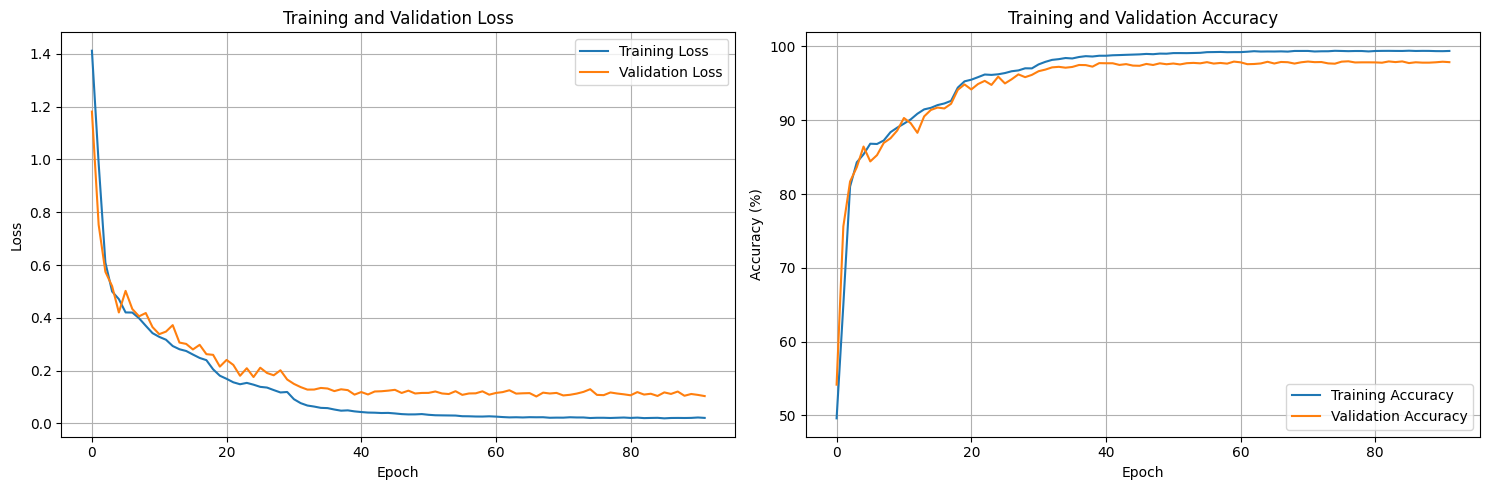


Final Test Accuracy: 97.64%
🎉 Great performance achieved!


In [11]:


# Set device with memory management
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Clear GPU cache at start
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.set_per_process_memory_fraction(0.9)  # Use 90% of available GPU memory
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Network Architecture - Optimized for 64x64 RGB images
num_inputs = 64 * 64 * 1  # 12,288 for RGB images
num_hidden = 512          # Reduced from 1000 to fit GPU memory
num_outputs = 10

# Temporal Dynamics - Optimized
num_steps = 40           # Reduced from 25 to save memory
beta = 0.95

# Define Optimized Network
class OptimizedNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers with batch normalization for better performance
        self.fc1 = nn.Linear(num_inputs, num_hidden, bias=False)
        self.bn1 = nn.BatchNorm1d(num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid(slope=25))
        
        self.fc2 = nn.Linear(num_hidden, num_hidden//2, bias=False)  # Additional layer for better feature extraction
        self.bn2 = nn.BatchNorm1d(num_hidden//2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid(slope=25))
        
        self.fc3 = nn.Linear(num_hidden//2, num_outputs, bias=False)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid(slope=25), output=True)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        batch_size = x.size(0)
        
        # Flatten the input images
        x = x.view(batch_size, -1)

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        # Memory-efficient spike accumulation instead of storing all timesteps
        spike_sum = torch.zeros(batch_size, num_outputs, device=x.device)

        for step in range(num_steps):
            # First layer
            cur1 = self.bn1(self.fc1(x))
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.dropout(spk1)
            
            # Second layer
            cur2 = self.bn2(self.fc2(spk1))
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = self.dropout(spk2)
            
            # Output layer
            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)
            
            # Accumulate spikes instead of storing all timesteps
            spike_sum += spk3
            
            # Clean up intermediate tensors for memory efficiency
            del cur1, spk1, cur2, spk2, cur3, spk3

        return spike_sum

# Optimized data augmentation
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.3),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])


# Load the network onto CUDA if available
net = OptimizedNet().to(device)

# Print model info
total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print("Model Architecture:")
print(net)

# Optimized loss function and optimizer
loss_fn = SF.ce_rate_loss()
optimizer = torch.optim.AdamW(net.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

# Mixed precision scaler for memory and speed optimization
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

def train_model(net, train_loader, val_loader, num_epochs=100, patience=15):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_val_acc = 0.0
    patience_counter = 0

    print("Starting optimized SNN training...")

    for epoch in range(num_epochs):
        # Training phase
        net.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for batch_idx, (data, targets) in enumerate(train_bar):
            data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            optimizer.zero_grad()

            # Mixed precision forward pass
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = net(data)
                    loss = loss_fn(outputs.unsqueeze(0), targets)  # Add time dimension for loss
                
                # Mixed precision backward pass
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = net(data)
                loss = loss_fn(outputs.unsqueeze(0), targets)
                loss.backward()
                optimizer.step()

            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

            # Memory management
            if batch_idx % 10 == 0 and torch.cuda.is_available():
                torch.cuda.empty_cache()

            train_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct_train/total_train:.2f}%'
            })

            del data, targets, outputs, loss

        # Validation phase
        net.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
            for data, targets in val_bar:
                data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        outputs = net(data)
                        loss = loss_fn(outputs.unsqueeze(0), targets)
                else:
                    outputs = net(data)
                    loss = loss_fn(outputs.unsqueeze(0), targets)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()

                val_bar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Acc': f'{100.*correct_val/total_val:.2f}%'
                })

                del data, targets, outputs, loss

        # Calculate epoch metrics
        epoch_train_loss = running_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_train_acc = 100. * correct_train / total_train
        epoch_val_acc = 100. * correct_val / total_val

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')
        print(f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')
        
        if torch.cuda.is_available():
            print(f'GPU Memory Used: {torch.cuda.memory_allocated() / 1024**3:.2f} GB')
        print('-' * 60)

        scheduler.step()

        # Early stopping and model saving
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            patience_counter = 0
            torch.save(net.state_dict(), 'best_simple_snn_model.pth')
            print(f'New best validation accuracy: {best_val_acc:.2f}%')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs')
            break

        # Clear cache after each epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    return train_losses, val_losses, train_accuracies, val_accuracies

def test_model(net, test_loader):
    net.eval()
    correct = 0
    total = 0
    class_correct = list(0. for i in range(num_outputs))
    class_total = list(0. for i in range(num_outputs))

    with torch.no_grad():
        test_bar = tqdm(test_loader, desc='Testing')
        for data, targets in test_bar:
            data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = net(data)
            else:
                outputs = net(data)
            
            _, predicted = torch.max(outputs, 1)

            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            # Per-class accuracy
            c = (predicted == targets).squeeze()
            for i in range(targets.size(0)):
                label = targets[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

            test_bar.set_postfix({'Acc': f'{100.*correct/total:.2f}%'})
            
            del data, targets, outputs, predicted

    test_accuracy = 100. * correct / total
    print(f'\nTest Accuracy: {test_accuracy:.2f}%')

    # Print per-class accuracy
    class_names = ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark',
                   'drilling', 'engine_idling', 'gun_shot', 'jackhammer',
                   'siren', 'street_music']

    print("\nPer-class accuracy:")
    for i in range(num_outputs):
        if class_total[i] > 0:
            class_acc = 100 * class_correct[i] / class_total[i]
            print(f'{class_names[i]}: {class_acc:.2f}%')

    return test_accuracy

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot losses
    ax1.plot(train_losses, label='Training Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot accuracies
    ax2.plot(train_accuracies, label='Training Accuracy')
    ax2.plot(val_accuracies, label='Validation Accuracy')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('simple_snn_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Train the model
print("Training Simple SNN model for environmental sound recognition...")
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    net, train_loader, val_loader, num_epochs=100, patience=15
)

# Load best model and test
net.load_state_dict(torch.load('best_simple_snn_model.pth'))
test_accuracy = test_model(net, test_loader)

# Plot training history
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

print(f"\nFinal Test Accuracy: {test_accuracy:.2f}%")
if test_accuracy >= 90.0:
    print("🎉 Great performance achieved!")
else:
    print("💡 Consider fine-tuning hyperparameters for better performance.")

# Clear GPU memory at the end
if torch.cuda.is_available():
    torch.cuda.empty_cache()